# Análisis de Egresos Hospitalarios — Provincia de Buenos Aires (2016-2020)

## Notebook 01 — Exploración inicial (EDA)

**Autor:** Franco Vigna  
**Dataset:** Egresos hospitalarios del sistema de salud provincial (PBA)  
**Fuente:** [Datos Abiertos PBA - Ministerio de Salud](https://catalogo.datos.gba.gob.ar/dataset/egresos-hospitalarios)  
**Licencia:** Creative Commons Attribution 4.0

### Objetivo de este notebook

Hacer una primera exploración (EDA) del dataset para entender:

- ¿Qué información tenemos? (columnas, tipos de datos, calidad)
- ¿Hay nulos o inconsistencias?
- ¿Cuáles son las causas más frecuentes de egreso?
- ¿Cómo se distribuyen los egresos por región y año?

Uso DuckDB para correr **SQL directamente sobre los DataFrames** de pandas. Es una herramienta moderna que combina lo mejor de los dos mundos.

## 1. Imports y configuración

In [1]:
import sys
from pathlib import Path

# Agregar la carpeta /app al path para importar data_loader
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "app"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

from data_loader import cargar_dataset

# Estilo de gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Entorno listo.")

Entorno listo.


## 2. Carga del dataset

Uso el helper `cargar_dataset()` que normaliza los nombres de columnas y concatena todos los años en un solo DataFrame.

In [2]:
df = cargar_dataset()
print(f"Filas:    {len(df):,}")
print(f"Columnas: {len(df.columns)}")
print(f"Años:     {sorted(df['anio'].dropna().unique().tolist())}")
df.head()

Filas:    790,990
Columnas: 11
Años:     [2016, 2017, 2018, 2019, 2020]


,anio,region_sanitaria,municipio,muncipio_id,sexo,grupo_edad,causa,causa_egreso_agrupamiento,tipo_egreso,cantidad_egresos,municipio_id
0,2016,VI,Almirante Brown,6028.0,Ignorado,0-4,Afecciones perinatales,Todos,Alta definitiva,1,NaN
1,2016,VI,Almirante Brown,6028.0,Ignorado,0-4,Enfermedad de la piel y del tejido subcutáneo,Todos,Alta definitiva,1,NaN
2,2016,VI,Almirante Brown,6028.0,Ignorado,15-19,"Embarazo, parto y puerperio",Complicaciones del trabajo de parto y del parto,Alta definitiva,2,NaN
3,2016,VI,Almirante Brown,6028.0,Ignorado,15-19,"Embarazo, parto y puerperio",Parto,Alta definitiva,1,NaN
4,2016,VI,Almirante Brown,6028.0,Ignorado,15-19,"Malformación congénitas, deformación y anomalí...",Todos,Alta definitiva,1,NaN


## 3. Calidad de datos

Antes de analizar, hay que entender la calidad: tipos, nulos, duplicados, valores raros.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790990 entries, 0 to 790989
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   anio                       788697 non-null  Int64  
 1   region_sanitaria           788697 non-null  str    
 2   municipio                  788697 non-null  str    
 3   muncipio_id                315187 non-null  float64
 4   sexo                       788697 non-null  str    
 5   grupo_edad                 788697 non-null  str    
 6   causa                      788697 non-null  str    
 7   causa_egreso_agrupamiento  788697 non-null  str    
 8   tipo_egreso                788697 non-null  str    
 9   cantidad_egresos           790990 non-null  int64  
 10  municipio_id               473510 non-null  float64
dtypes: Int64(1), float64(2), int64(1), str(7)
memory usage: 157.5 MB


In [4]:
# Cantidad de nulos por columna
nulos = df.isna().sum().to_frame("nulos")
nulos["%"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos.sort_values("nulos", ascending=False)

,nulos,%
muncipio_id,475803,60.15
municipio_id,317480,40.14
anio,2293,0.29
municipio,2293,0.29
region_sanitaria,2293,0.29
grupo_edad,2293,0.29
sexo,2293,0.29
causa,2293,0.29
causa_egreso_agrupamiento,2293,0.29
tipo_egreso,2293,0.29


In [5]:
# Estadísticos descriptivos de las numéricas
df.describe().round(2)

,anio,muncipio_id,cantidad_egresos,municipio_id
count,788697.0,315187.00,790990.00,473510.00
mean,2018.03,6458.66,5.76,6458.92
std,1.4,250.50,28.98,249.31
min,2016.0,6007.00,0.00,6007.00
25%,2017.0,6252.00,1.00,6252.00
50%,2018.0,6462.00,2.00,6462.00
75%,2019.0,6665.00,4.00,6665.00
max,2020.0,6882.00,2938.00,6882.00


## 4. Exploración con SQL (DuckDB)

DuckDB permite correr SQL directamente sobre el DataFrame de pandas. La sintaxis es estándar (SELECT, JOIN, GROUP BY, etc.) y es lo que se usa en la mayoría de los trabajos de Data Analyst.

In [6]:
# Conexión en memoria a DuckDB. 
# La tabla 'df' queda disponible para consultar como si fuera una tabla SQL.
con = duckdb.connect()
con.register("egresos", df)
print("Tabla 'egresos' registrada en DuckDB.")

Tabla 'egresos' registrada en DuckDB.


### 4.1 Top 10 causas de egreso

¿Por qué motivos se interna y se da de alta más gente?

In [7]:
q = """
SELECT 
    causa,
    SUM(cantidad_egresos) AS total_egresos,
    ROUND(100.0 * SUM(cantidad_egresos) / SUM(SUM(cantidad_egresos)) OVER (), 2) AS pct
FROM egresos
GROUP BY causa
ORDER BY total_egresos DESC
LIMIT 10;
"""
top_causas = con.execute(q).df()
top_causas

,causa,total_egresos,pct
0,"Embarazo, parto y puerperio",774548.0,17.00
1,Enfermedad del sistema respiratorio,539670.0,11.84
2,"Traumatismos, envenenamientos y algunas otras ...",496710.0,10.90
3,"Síntomas, signos y hallazgos anormales clínico...",496679.0,10.90
4,Enfermedad del sistema digestivo,418884.0,9.19
5,Enfermedad del sistema circulatorio,352826.0,7.74
6,Enfermedad del sistema genitourinario,247800.0,5.44
7,Ciertas enfermedades infecciosas y parasitarias,170925.0,3.75
8,Factores que influyen en el estado de salud y ...,145104.0,3.18
9,Afecciones perinatales,134234.0,2.95


### 4.2 Distribución por región sanitaria

In [8]:
q = """
SELECT 
    region_sanitaria,
    SUM(cantidad_egresos) AS total_egresos
FROM egresos
GROUP BY region_sanitaria
ORDER BY total_egresos DESC;
"""
por_region = con.execute(q).df()
por_region

,region_sanitaria,total_egresos
0,V,1505178.0
1,VI,517913.0
2,VII,497749.0
3,XI,383719.0
4,VIII,366607.0
5,IV,259676.0
6,XII,202909.0
7,I,198167.0
8,IX,192293.0
9,II,192282.0


### 4.3 Evolución temporal: egresos por año

In [9]:
q = """
SELECT 
    anio,
    SUM(cantidad_egresos) AS total_egresos
FROM egresos
GROUP BY anio
ORDER BY anio;
"""
por_anio = con.execute(q).df()
por_anio

,anio,total_egresos
0,2016,816446.0
1,2017,884810.0
2,2018,918788.0
3,2019,1024615.0
4,2020,912353.0
5,<NA>,0.0


### 4.4 Días de estadía por causa (top 10)

In [10]:
# La columna dias_estadia_promedio no existe en el dataset real.
# Se omite el analisis de estadia por causa.
print("Columna dias_estadia_promedio no disponible en este dataset. Seccion omitida.")

Columna dias_estadia_promedio no disponible en este dataset. Seccion omitida.


## 5. Visualizaciones

Las consultas SQL me dieron los números — ahora los hago entendibles a primera vista.

### 5.1 Top 10 causas de egreso

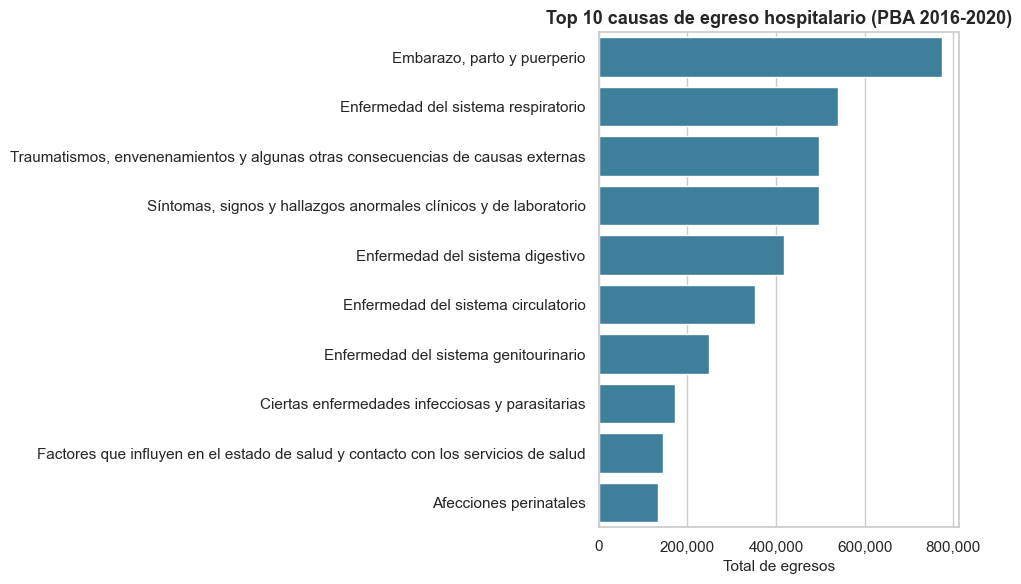

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_causas.head(10),
    y="causa", x="total_egresos",
    color="#2E86AB", ax=ax
)
ax.set_title("Top 10 causas de egreso hospitalario (PBA 2016-2020)", fontweight="bold")
ax.set_xlabel("Total de egresos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../assets/01_top_causas.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Evolución temporal de egresos

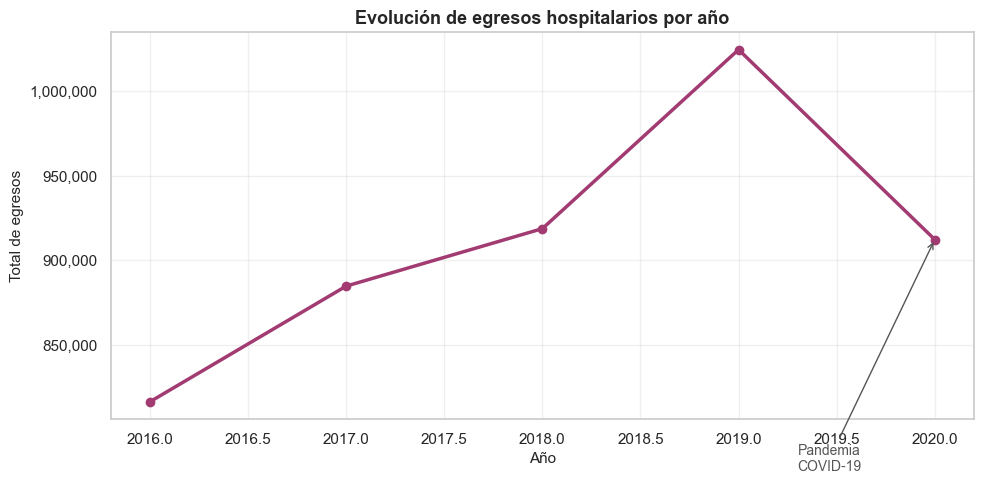

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(por_anio["anio"], por_anio["total_egresos"],
        marker="o", linewidth=2.5, color="#A23B72")
ax.set_title("Evolución de egresos hospitalarios por año", fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Total de egresos")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, alpha=0.3)

# Anotar el bajón de 2020 (pandemia)
if 2020 in por_anio["anio"].values:
    valor_2020 = por_anio.loc[por_anio["anio"] == 2020, "total_egresos"].iloc[0]
    ax.annotate("Pandemia\nCOVID-19",
                xy=(2020, valor_2020),
                xytext=(2019.3, valor_2020 * 0.85),
                arrowprops=dict(arrowstyle="->", color="#555"),
                fontsize=10, color="#555")

plt.tight_layout()
plt.savefig("../assets/02_evolucion_anual.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.3 Egresos por región sanitaria

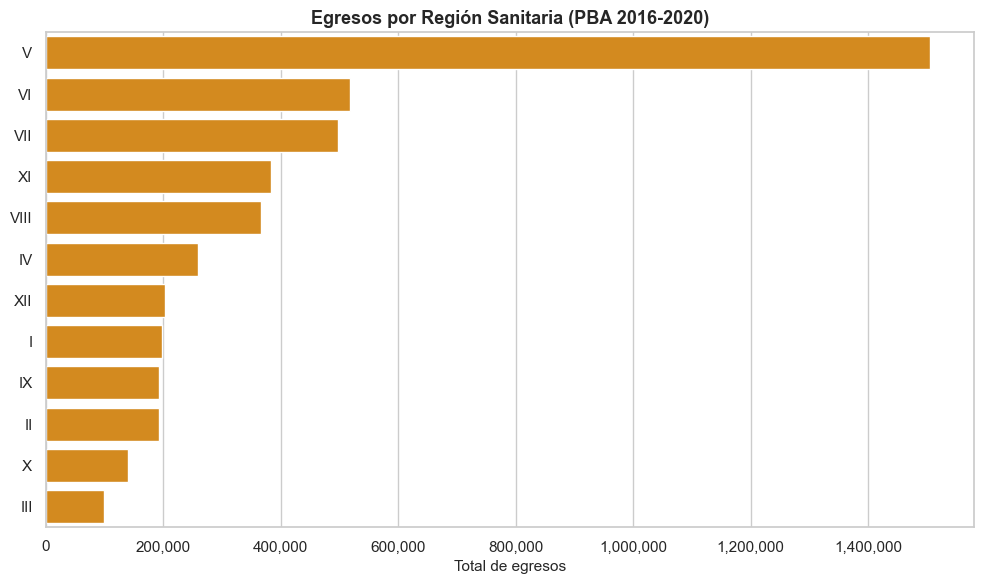

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=por_region,
    y="region_sanitaria", x="total_egresos",
    color="#F18F01", ax=ax
)
ax.set_title("Egresos por Región Sanitaria (PBA 2016-2020)", fontweight="bold")
ax.set_xlabel("Total de egresos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../assets/03_por_region.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4 Distribución de tipo de egreso

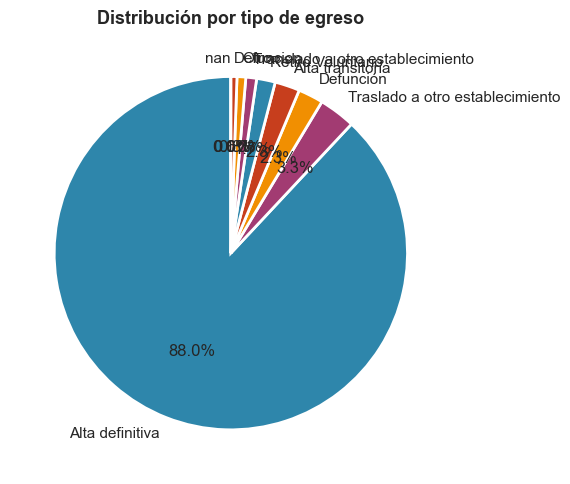

In [14]:
q = """
SELECT 
    tipo_egreso,
    SUM(cantidad_egresos) AS total
FROM egresos
GROUP BY tipo_egreso
ORDER BY total DESC;
"""
por_tipo = con.execute(q).df()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]
ax.pie(por_tipo["total"], labels=por_tipo["tipo_egreso"],
       autopct="%1.1f%%", colors=colors[:len(por_tipo)],
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Distribución por tipo de egreso", fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/04_tipo_egreso.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Guardado del dataset limpio

Guardo el DataFrame ya normalizado en `data/processed/` para que el notebook de análisis profundo y la app Streamlit lo levanten más rápido.

In [15]:
destino = ROOT / "data" / "processed" / "egresos_2016_2020.parquet"
destino.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(destino, index=False)
print(f"Guardado: {destino} ({destino.stat().st_size / 1024:,.1f} KB)")

Guardado: C:\Users\Franco\Documents\Claude\proyecto_salud\data\processed\egresos_2016_2020.parquet (1,884.8 KB)


## 7. Hallazgos preliminares

_(Completá esta sección con tu análisis cuando corras el notebook con datos reales.)_

- **Top causa de egreso:** _causa con mayor volumen_  
- **Estadía más larga:** _patologías que requieren más días_  
- **Impacto pandemia:** _baja relativa de egresos en 2020_  
- **Distribución regional:** _concentración en el conurbano_  

→ Continúa en `02_analisis.ipynb` con cortes más profundos.